In [55]:
# !pip install plotly

In [72]:
from pycoingecko import CoinGeckoAPI
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import warnings
warnings.filterwarnings('ignore')

In [73]:
cg = CoinGeckoAPI()

In [74]:
bitcoin_data = cg.get_coin_market_chart_by_id(id= 'bitcoin', vs_currency='inr',days= 30)
bitcoin_data

{'prices': [[1775055716129, 6397124.646101557],
  [1775059280844, 6420737.179277752],
  [1775062975213, 6399465.261446031],
  [1775066579538, 6324738.524461838],
  [1775070202403, 6301641.546113529],
  [1775073749796, 6318118.917784668],
  [1775077384455, 6315939.473692746],
  [1775080927324, 6345850.163668911],
  [1775084537247, 6310271.058694713],
  [1775088146271, 6307964.144411761],
  [1775091722785, 6355673.540849406],
  [1775095209661, 6249967.061279795],
  [1775098964669, 6226052.500251197],
  [1775102440582, 6212205.603382414],
  [1775106108290, 6208866.219338527],
  [1775109752765, 6228890.4685042165],
  [1775113357302, 6216619.602310267],
  [1775116999034, 6217792.160567812],
  [1775120577195, 6163009.471874381],
  [1775124022705, 6172477.215741898],
  [1775127743066, 6187574.275267216],
  [1775131355895, 6170399.183106399],
  [1775134816343, 6144637.531864336],
  [1775138564014, 6160932.970768904],
  [1775142169441, 6215907.489905714],
  [1775145781508, 6210829.105293746],
 

In [75]:
df = pd.DataFrame(bitcoin_data['prices'], columns=['Date','Price'])
df

,Date,Price
0,1775055716129,6.397125e+06
1,1775059280844,6.420737e+06
2,1775062975213,6.399465e+06
3,1775066579538,6.324739e+06
4,1775070202403,6.301642e+06
...,...,...
722,1777633254545,7.327017e+06
723,1777636845526,7.350910e+06
724,1777640442692,7.401672e+06
725,1777644070071,7.461030e+06


In [76]:
df['Date'] = pd.to_datetime(df['Date'],unit = 'ms')

In [77]:
df

,Date,Price
0,2026-04-01 15:01:56.129,6.397125e+06
1,2026-04-01 16:01:20.844,6.420737e+06
2,2026-04-01 17:02:55.213,6.399465e+06
3,2026-04-01 18:02:59.538,6.324739e+06
4,2026-04-01 19:03:22.403,6.301642e+06
...,...,...
722,2026-05-01 11:00:54.545,7.327017e+06
723,2026-05-01 12:00:45.526,7.350910e+06
724,2026-05-01 13:00:42.692,7.401672e+06
725,2026-05-01 14:01:10.071,7.461030e+06


In [78]:
group = df.groupby(df['Date'].dt.date).agg({'Price':['max','min','first','last']})
group

Price                                          
                     max           min         first          last
Date                                                              
2026-04-01  6.420737e+06  6.301642e+06  6.397125e+06  6.310271e+06
2026-04-02  6.355674e+06  6.144638e+06  6.307964e+06  6.231106e+06
2026-04-03  6.219176e+06  6.158287e+06  6.219176e+06  6.205375e+06
2026-04-04  6.269841e+06  6.204001e+06  6.209570e+06  6.265604e+06
2026-04-05  6.352239e+06  6.207897e+06  6.257967e+06  6.352239e+06
2026-04-06  6.498918e+06  6.398737e+06  6.414171e+06  6.405155e+06
2026-04-07  6.630927e+06  6.312148e+06  6.401867e+06  6.630927e+06
2026-04-08  6.683689e+06  6.546592e+06  6.683689e+06  6.561544e+06
2026-04-09  6.693365e+06  6.537806e+06  6.562922e+06  6.661170e+06
2026-04-10  6.816407e+06  6.625065e+06  6.636645e+06  6.789859e+06
2026-04-11  6.846819e+06  6.773265e+06  6.782191e+06  6.801701e+06
2026-04-12  6.804682e+06  6.589983e+06  6.794806e+06  6.600589e+06
2026-04-13  7.073515e+06  6.596926e+06  6.685979e+06  7.073515e+06
2026-04-14  7.073662e+06  6.900224e+06  7.073662e+06  6.903926e+06
2026-04-15  7.003452e+06  6.886265e+06  6.911131e+06  7.003452e+06
2026-04-16  7.012302e+06  6.876088e+06  6.986377e+06  6.967744e+06
2026-04-17  7.203995e+06  6.916532e+06  6.992493e+06  7.158951e+06
2026-04-18  7.159597e+06  7.005703e+06  7.142283e+06  7.022062e+06
2026-04-19  7.040079e+06  6.865357e+06  7.012641e+06  6.865357e+06
2026-04-20  7.118132e+06  6.839334e+06  6.839334e+06  7.076732e+06
2026-04-21  7.168796e+06  7.028499e+06  7.065729e+06  7.080619e+06
2026-04-22  7.440407e+06  7.140614e+06  7.148144e+06  7.373002e+06
2026-04-23  7.374190e+06  7.281263e+06  7.334730e+06  7.363598e+06
2026-04-24  7.393100e+06  7.276983e+06  7.365353e+06  7.276983e+06
2026-04-25  7.319493e+06  7.268394e+06  7.284891e+06  7.296927e+06
2026-04-26  7.387837e+06  7.282821e+06  7.301369e+06  7.385094e+06
2026-04-27  7.470332e+06  7.210705e+06  7.412346e+06  7.264361e+06
2026-04-28  7.294099e+06  7.183169e+06  7.291979e+06  7.214789e+06
2026-04-29  7.360858e+06  7.163105e+06  7.225751e+06  7.204883e+06
2026-04-30  7.255536e+06  7.189457e+06  7.192314e+06  7.219655e+06
2026-05-01  7.461030e+06  7.228866e+06  7.228866e+06  7.435002e+06

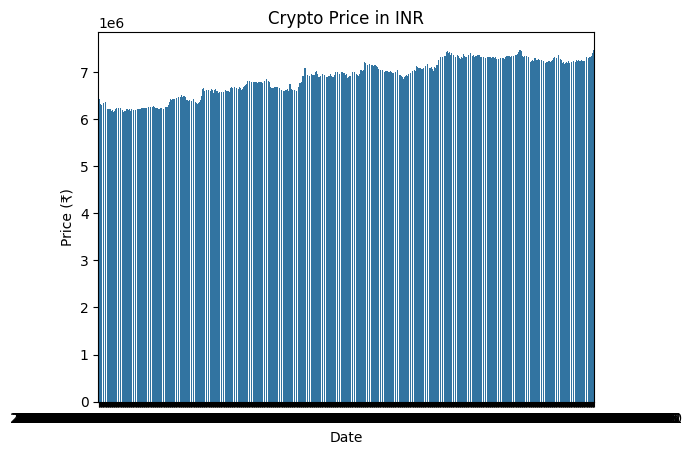

In [79]:
sns.barplot(x=df['Date'], y=df['Price'])
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.title("Crypto Price in INR")
plt.show()

In [80]:
import plotly.graph_objects as go

df.set_index('Date', inplace=True)


ohlc = df['Price'].resample('D').ohlc()
ohlc.reset_index(inplace=True)

fig = go.Figure(data=[go.Candlestick(
    x=ohlc['Date'],
    open=ohlc['open'],
    high=ohlc['high'],
    low=ohlc['low'],
    close=ohlc['close']
)])

fig.update_layout(
    title='Bitcoin Candlestick Chart (INR)',
    xaxis_title='Date',
    yaxis_title='Price',
    xaxis_rangeslider_visible=False
)

fig.show()

In [81]:
profile = ProfileReport(df,title='Bitcoin Analysis')
profile.to_file('bitcoin_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 157.04it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]